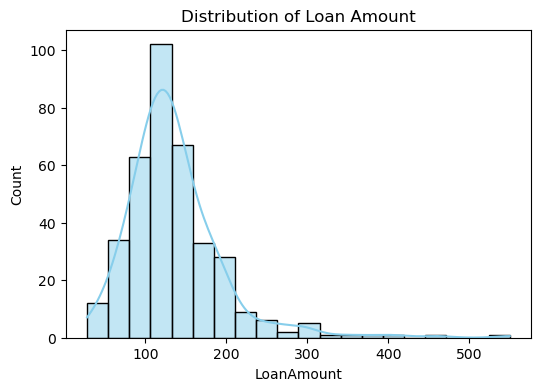

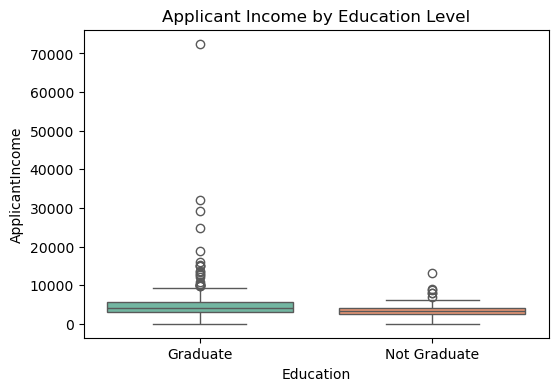

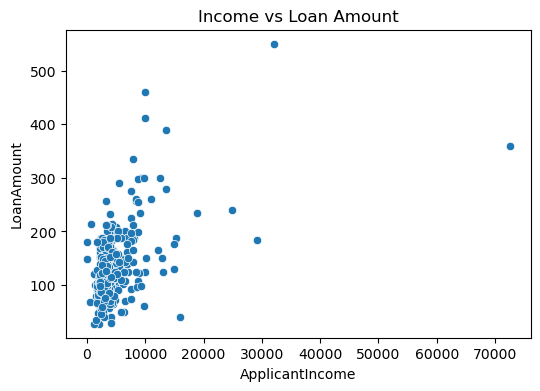

Model Accuracy: 1.0000

Confusion Matrix:
[[19  0]
 [ 0 55]]


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

# ---------------------------------------------------------
# 1. LOAD DATA & DATA CLEANING
# ---------------------------------------------------------
# Load the dataset using pandas 
df = pd.read_csv('loan_data.csv.csv')

# Handle missing data appropriately 
# Using median for numerical and mode for categorical columns
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

# ---------------------------------------------------------
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ---------------------------------------------------------
# Visualize key features: loan amount, education, and income 

# Histogram for Loan Amount [cite: 19]
plt.figure(figsize=(6, 4))
sns.histplot(df['LoanAmount'], bins=20, color='skyblue', kde=True)
plt.title('Distribution of Loan Amount')
plt.show()

# Box plot for Income by Education [cite: 20]
# Updated to avoid FutureWarning
plt.figure(figsize=(6, 4))
sns.boxplot(x='Education', y='ApplicantIncome', data=df, hue='Education', palette='Set2', legend=False)
plt.title('Applicant Income by Education Level')
plt.show()

# Scatter plot for Income vs Loan Amount [cite: 18]
plt.figure(figsize=(6, 4))
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', data=df)
plt.title('Income vs Loan Amount')
plt.show()

# ---------------------------------------------------------
# 3. DATA PREPARATION & MODELING
# ---------------------------------------------------------
# Create a target column 'Loan_Status' (Predicting loan default) 
# We assume Credit_History as a primary driver for approval
df['Loan_Status'] = np.where(df['Credit_History'] == 1.0, 'Y', 'N')

# Drop ID and create dummy variables for categorical features 
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)
X = pd.get_dummies(X, drop_first=True)
y = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Split the data into training and testing sets [cite: 85]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling to ensure model convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Logistic Regression classification model [cite: 34]
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# ---------------------------------------------------------
# 4. EVALUATION
# ---------------------------------------------------------
# Predict and evaluate the model using accuracy and a confusion matrix 
predictions = model.predict(X_test_scaled)

print(f"Model Accuracy: {accuracy_score(y_test, predictions):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))